# Lecture 10.2 — Principal Component Analysis (PCA)

---

## What is PCA?

**Principal Component Analysis (PCA)** is one of the most widely used techniques in
machine learning and data analysis. It serves two main purposes:

1. **Dimensionality reduction** — shrink a dataset with many features down to fewer
   features while keeping as much information as possible.
2. **Exploratory analysis** — visualize high-dimensional data in 2D to spot patterns.

### The five steps of PCA (from the lecture)

| Step | Action |
|------|--------|
| 1 | **Standardize** the data (center and scale each feature to z-scores) |
| 2 | **Compute the covariance matrix** S = (1/(n-1)) · AᵀA |
| 3 | **Find eigenvectors of S** via SVD of A |
| 4 | **Identify principal components** sorted by descending eigenvalue |
| 5 | **Project** the data onto the top k principal components |

---

## Setup

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn import preprocessing
from sklearn.decomposition import PCA as SklearnPCA

sns.set_theme()

## Load and Clean the Bee Colony Loss Dataset

The dataset has percentage strings like `'7.6%'` stored as text, so we need to
strip the `%` sign and convert every column to a proper number before we can do
any math on it.


In [8]:
df = pd.read_csv('data/Bee_Colony_Loss.csv')
print('Raw shape:', df.shape)
print()
print(df.head())


Raw shape: (568, 7)

   index       State Total Winter All Loss Beekeepers  \
0      0    Maryland                  7.6%         14   
1      1  Washington                 13.7%          5   
2      2  New Jersey                 15.1%         15   
3      3    Arkansas                 17.4%         20   
4      4       Maine                   18%          6   

  Beekeepers Exclusive to State Colonies Colonies Exclusive to State  
0                          100%     4013                        100%  
1                            0%    21870                          0%  
2                           80%    22622                         12%  
3                          100%    16955                        100%  
4                         16.7%    45937                        0.1%  


In [9]:
def strip_percent(series):
    """Remove the % character and convert to float."""
    return pd.to_numeric(series.str.replace('%', '', regex=False), errors='coerce')

for col in feature_cols:
    df[col] = strip_percent(df[col])

df_clean = df[feature_cols].dropna()
X = df_clean.to_numpy().astype(float)

print('Feature matrix shape:', X.shape)
print()
print(df_clean.head())


Feature matrix shape: (557, 5)

   Total Winter All Loss  Beekeepers  Beekeepers Exclusive to State  Colonies  \
0                    7.6        14.0                          100.0    4013.0   
1                   13.7         5.0                            0.0   21870.0   
2                   15.1        15.0                           80.0   22622.0   
3                   17.4        20.0                          100.0   16955.0   
4                   18.0         6.0                           16.7   45937.0   

   Colonies Exclusive to State  
0                        100.0  
1                          0.0  
2                         12.0  
3                        100.0  
4                          0.1  


---

## Step 1 — Standardize the Data

Before running PCA we must convert every feature to a **z-score**:

$$z = \frac{x - \mu}{\sigma}$$

Without this, features with large ranges (e.g. `Colonies` in the thousands)
would completely dominate features with small ranges (e.g. `Total Winter All Loss`
which is 0–100%), and PCA would just find the direction of the noisiest feature.


In [10]:
scaled_X = preprocessing.scale(X)

print('Mean of each feature after scaling (should be ~0):')
print(np.round(scaled_X.mean(axis=0), 6))
print()
print('Std of each feature after scaling (should be ~1):')
print(np.round(scaled_X.std(axis=0), 4))


Mean of each feature after scaling (should be ~0):
[-0.  0.  0.  0.  0.]

Std of each feature after scaling (should be ~1):
[1. 1. 1. 1. 1.]


---

## Steps 2–4 — SVD from Scratch

The professor's notes show that principal components are the **right singular vectors**
of the centered data matrix A, from the decomposition:

$$A = U \Sigma V^T$$

The rows of **Vᵀ** are the principal component directions, automatically sorted
from largest to smallest singular value.


In [11]:
# Center the data (already done by preprocessing.scale above)
A = scaled_X

# Singular Value Decomposition
U, sigma, Vt = np.linalg.svd(A, full_matrices=False)

print('Shape of U     (n_samples × n_features):', U.shape)
print('Shape of sigma (n_features,)            :', sigma.shape)
print('Shape of Vt    (n_features × n_features):', Vt.shape)
print()

# Verify reconstruction
sigma_mat = np.diag(sigma)
print('A == U · Σ · Vᵀ:', np.allclose(A, U @ sigma_mat @ Vt))


Shape of U     (n_samples × n_features): (557, 5)
Shape of sigma (n_features,)            : (5,)
Shape of Vt    (n_features × n_features): (5, 5)

A == U · Σ · Vᵀ: True


In [12]:
# Each ROW of Vt is a principal component direction
PC1 = Vt[0]
PC2 = Vt[1]

print('PC1 (loading scores per original feature):')
for name, score in zip(feature_cols, PC1):
    print(f'  {name:35s}: {score:+.4f}')

print()
print('PC2 (loading scores per original feature):')
for name, score in zip(feature_cols, PC2):
    print(f'  {name:35s}: {score:+.4f}')


PC1 (loading scores per original feature):
  Total Winter All Loss              : +0.2581
  Beekeepers                         : +0.1069
  Beekeepers Exclusive to State      : +0.5972
  Colonies                           : -0.5571
  Colonies Exclusive to State        : +0.5049

PC2 (loading scores per original feature):
  Total Winter All Loss              : +0.2002
  Beekeepers                         : +0.9367
  Beekeepers Exclusive to State      : +0.0600
  Colonies                           : +0.2716
  Colonies Exclusive to State        : -0.0720


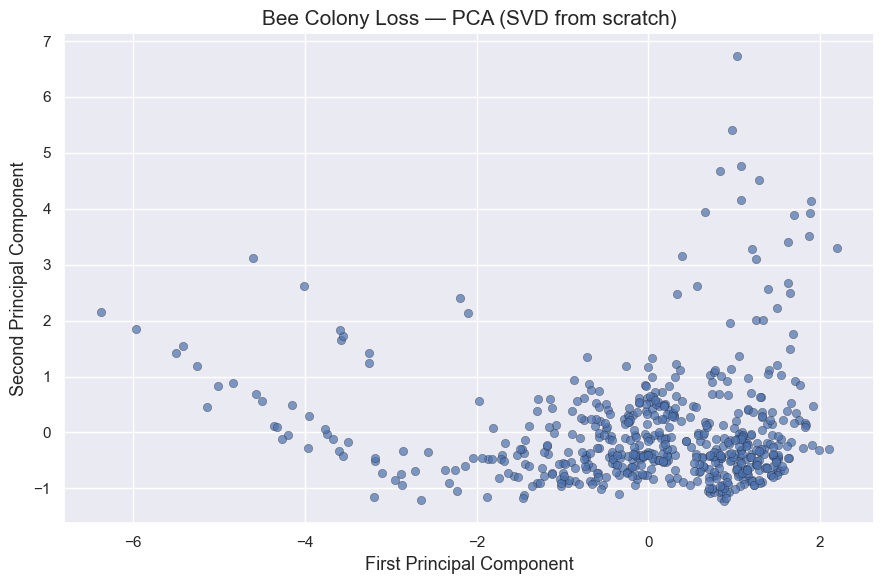

In [13]:
# Project onto the first 2 PCs: X2D = A · [PC1 | PC2]
W2  = Vt[:2].T      # (n_features, 2)
X2D = A @ W2        # (n_samples, 2)

plt.figure(figsize=(9, 6))
plt.scatter(X2D[:, 0], X2D[:, 1], alpha=0.7, edgecolors='k', linewidths=0.3)
plt.xlabel('First Principal Component', fontsize=13)
plt.ylabel('Second Principal Component', fontsize=13)
plt.title('Bee Colony Loss — PCA (SVD from scratch)', fontsize=15)
plt.tight_layout()
plt.show()


---

## Using Scikit-learn's PCA

In practice we use `sklearn.decomposition.PCA` which is faster and gives us
handy extras like `explained_variance_ratio_`.


In [14]:
pca = SklearnPCA()
pca.fit(scaled_X)

per_var = np.round(pca.explained_variance_ratio_ * 100, 2)
labels  = [f'PC{i}' for i in range(1, len(per_var) + 1)]

print('Variance explained by each principal component:')
for label, pv in zip(labels, per_var):
    print(f'  {label}: {pv}%')

print(f'\nTotal explained by first 2 PCs: {per_var[0] + per_var[1]:.1f}%')


Variance explained by each principal component:
  PC1: 43.03%
  PC2: 20.78%
  PC3: 18.54%
  PC4: 12.22%
  PC5: 5.42%

Total explained by first 2 PCs: 63.8%


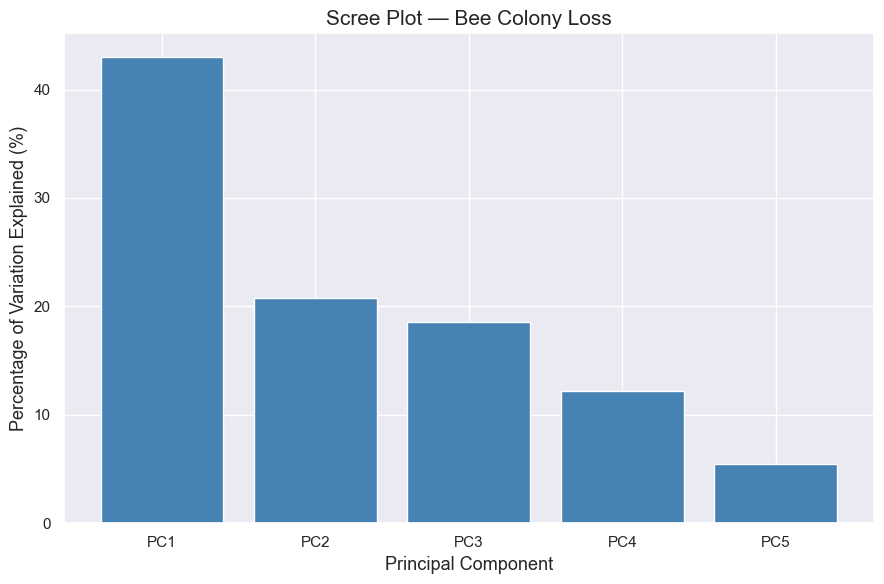


How to read a Scree Plot:
  • Each bar = how much total variance that PC captures.
  • Bars add up to 100%.
  • Keep PCs until you've explained ~80-90% of variance.
  • The 'elbow' suggests the right number of PCs to keep.



In [15]:
# Scree Plot
plt.figure(figsize=(9, 6))
plt.bar(x=range(1, len(per_var) + 1), height=per_var,
        tick_label=labels, color='steelblue')
plt.xlabel('Principal Component', fontsize=13)
plt.ylabel('Percentage of Variation Explained (%)', fontsize=13)
plt.title('Scree Plot — Bee Colony Loss', fontsize=15)
plt.tight_layout()
plt.show()

print("""
How to read a Scree Plot:
  • Each bar = how much total variance that PC captures.
  • Bars add up to 100%.
  • Keep PCs until you've explained ~80-90% of variance.
  • The 'elbow' suggests the right number of PCs to keep.
""")


In [16]:
# Loading scores — how each original feature contributes to each PC
loading_df = pd.DataFrame(
    pca.components_.T,
    index   = feature_cols,
    columns = labels
)
print('Loading scores (contribution of each feature to each PC):')
print(loading_df.to_string())


Loading scores (contribution of each feature to each PC):
                                    PC1       PC2       PC3       PC4       PC5
Total Winter All Loss          0.258119  0.200223  0.923595 -0.198059  0.032096
Beekeepers                     0.106917  0.936661 -0.226614 -0.010139 -0.244496
Beekeepers Exclusive to State  0.597181  0.060048 -0.249682 -0.206858  0.731189
Colonies                      -0.557136  0.271642  0.171959  0.450715  0.618948
Colonies Exclusive to State    0.504894 -0.071986  0.060887  0.845421 -0.146482


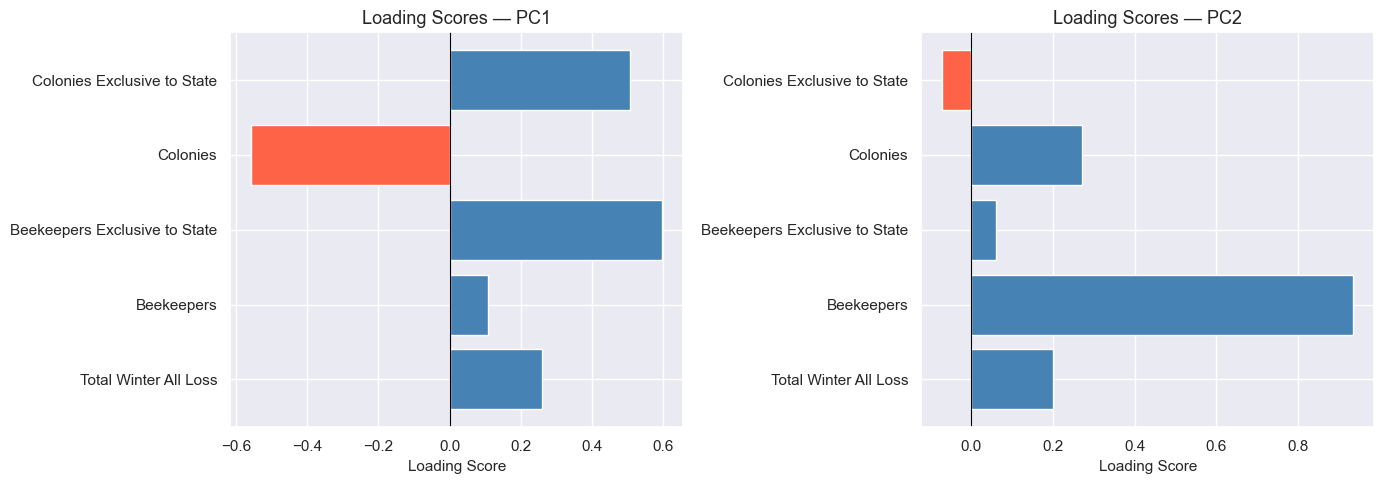


Blue = feature moves in same direction as the PC.
Red  = feature moves opposite to the PC.
Longer bar = stronger contribution.



In [17]:
# Visualise loading scores as horizontal bar charts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pc_idx, label in zip(axes, [0, 1], ['PC1', 'PC2']):
    scores = pca.components_[pc_idx]
    colors = ['steelblue' if s > 0 else 'tomato' for s in scores]
    ax.barh(feature_cols, scores, color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'Loading Scores — {label}', fontsize=13)
    ax.set_xlabel('Loading Score', fontsize=11)

plt.tight_layout()
plt.show()

print("""
Blue = feature moves in same direction as the PC.
Red  = feature moves opposite to the PC.
Longer bar = stronger contribution.
""")


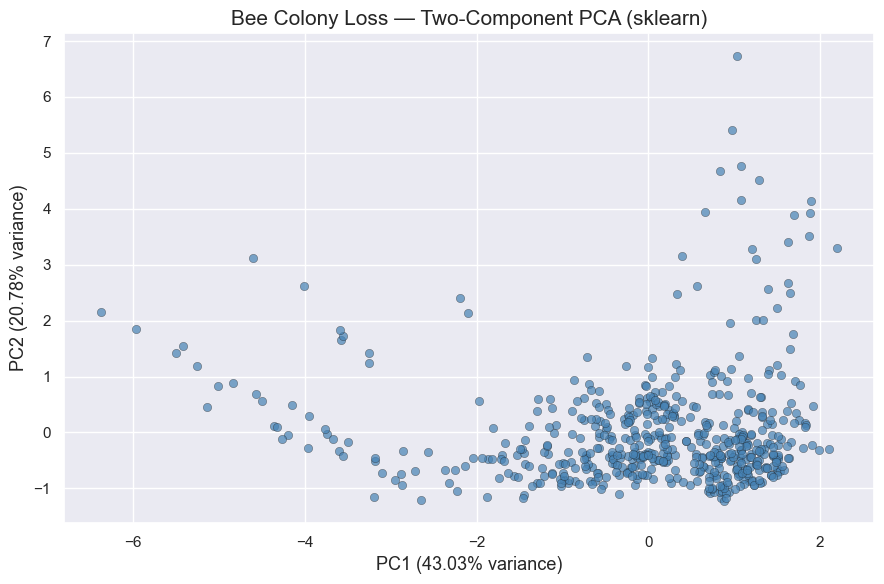

In [18]:
# Transform and plot in PC1–PC2 space
pca_data = pca.transform(scaled_X)
pca_df   = pd.DataFrame(pca_data, columns=labels)

plt.figure(figsize=(9, 6))
plt.scatter(pca_df['PC1'], pca_df['PC2'],
            alpha=0.7, edgecolors='k', linewidths=0.3, color='steelblue')
plt.xlabel(f'PC1 ({per_var[0]}% variance)', fontsize=13)
plt.ylabel(f'PC2 ({per_var[1]}% variance)', fontsize=13)
plt.title('Bee Colony Loss — Two-Component PCA (sklearn)', fontsize=15)
plt.tight_layout()
plt.show()


---

## Using Our Custom PCA Class


Projected shape: (557, 2)
Explained variance ratio: [0.43032392 0.20779459]


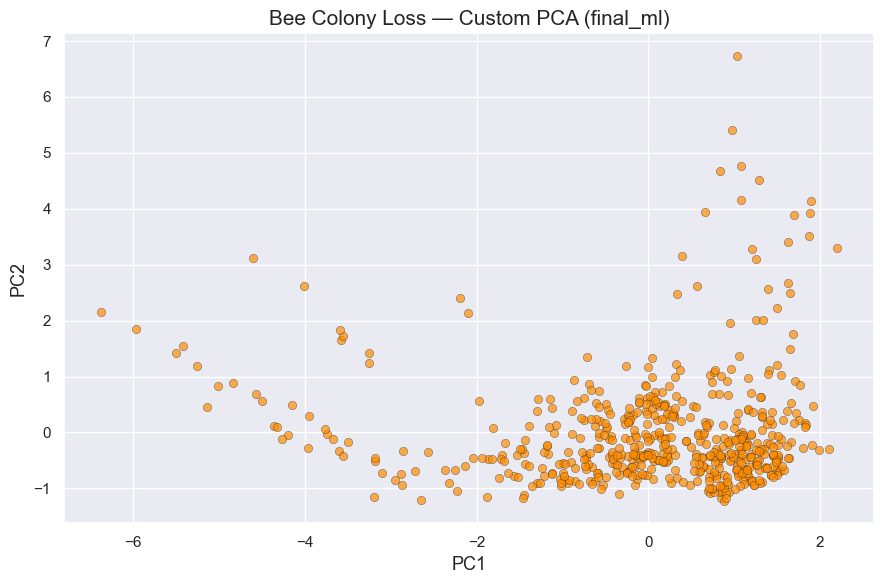

In [20]:
from final_ml.unsupervised_learning.pca import PCA

my_pca = PCA(n_components=2)
X_projected = my_pca.fit_transform(scaled_X)
print('Projected shape:', X_projected.shape)
print('Explained variance ratio:', my_pca.explained_variance_ratio_)

plt.figure(figsize=(9, 6))
plt.scatter(X_projected[:, 0], X_projected[:, 1],
            alpha=0.7, edgecolors='k', linewidths=0.3, color='darkorange')
plt.xlabel('PC1', fontsize=13)
plt.ylabel('PC2', fontsize=13)
plt.title('Bee Colony Loss — Custom PCA (final_ml)', fontsize=15)
plt.tight_layout()
plt.show()


---

## Summary

| Concept | What it means |
|---------|--------------|
| **Principal Component** | A new axis that is a linear combination of original features |
| **Loading score** | How much each original feature contributes to a PC |
| **Explained variance ratio** | Fraction of total variance captured by a PC |
| **Scree plot** | Bar chart used to choose how many PCs to keep |
| **SVD** | The math behind PCA: A = UΣVᵀ |

### Key takeaways
- Always **standardize** before PCA — otherwise large-range features dominate.
- The **scree plot elbow** tells you how many components to keep.
- **Loading scores** tell you which original features matter most.

**Next up:** K-Means Clustering!
